<h1 align="center"><font size = 14>Hands-On Machine Learning</font></h1>
<h3 align="center"><font size = 7>Naive Bayes Classifier</font></h3>
<h3 align="center">Zahra Amini</h3>
<br>
<br>
<br>
<br>
<br>

# Step0: Import Libraries

In [21]:
import re
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB, BernoulliNB
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Step1: Read Data

In [23]:
newsgroups = fetch_20newsgroups(subset='all', categories=None, shuffle=True, random_state=42)

# Step2: Data Preprocess

In [27]:
# newsgroups

In [47]:
def preprocess_text(text):
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.lower()
    return text

In [49]:
processed_data = [preprocess_text(doc) for doc in newsgroups.data]

In [50]:
# newsgroups.data

In [55]:
# processed_data

In [57]:
vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_df=0.7, min_df=5)

In [59]:
X = vectorizer.fit_transform(processed_data)

In [65]:
# X[1]

# Step3: Categorical

# Step4: X, y

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, newsgroups.target, test_size=0.3, random_state=42)

In [71]:
X_train.shape

(13192, 106735)

# Step5: Scaling

# Step6: Naive Bayes

In [73]:
models ={
    "MultinomialNB": MultinomialNB(),
    "ComplementNB": ComplementNB(),
    "BernoulliNB": BernoulliNB()
}

In [75]:
best_model_name = None
best_score = 0

In [77]:
for model_name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    avg_score = scores.mean()
    print(f"Model: {model_name}, CV Accuracy: {avg_score:.4f}")
    if avg_score > best_score:
        best_score = avg_score
        best_model_name = model_name

print(f"\nBest model: {best_model_name} with accuracy: {best_score:.4f}")

Model: MultinomialNB, CV Accuracy: 0.8679
Model: ComplementNB, CV Accuracy: 0.8934
Model: BernoulliNB, CV Accuracy: 0.7874

Best model: ComplementNB with accuracy: 0.8934


In [79]:
best_model = models[best_model_name]

best_model.fit(X_train, y_train)

ComplementNB()

In [81]:
y_pred = best_model.predict(X_test)

In [83]:
y_pred

array([ 9, 12, 14, ...,  0, 18,  1])

In [87]:
newsgroups.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [89]:
accuracy = metrics.accuracy_score(y_test, y_pred)

In [91]:
accuracy

0.8974177573399363

In [95]:
print(metrics.classification_report(y_pred, y_test, target_names=newsgroups.target_names))

                          precision    recall  f1-score   support

             alt.atheism       0.93      0.85      0.89       257
           comp.graphics       0.83      0.84      0.84       282
 comp.os.ms-windows.misc       0.87      0.88      0.88       286
comp.sys.ibm.pc.hardware       0.79      0.75      0.77       297
   comp.sys.mac.hardware       0.86      0.95      0.90       284
          comp.windows.x       0.88      0.91      0.90       297
            misc.forsale       0.81      0.85      0.83       262
               rec.autos       0.91      0.90      0.91       308
         rec.motorcycles       0.95      0.93      0.94       286
      rec.sport.baseball       0.94      0.95      0.95       305
        rec.sport.hockey       0.98      0.89      0.93       343
               sci.crypt       0.98      0.94      0.96       304
         sci.electronics       0.79      0.92      0.85       262
                 sci.med       0.94      0.92      0.93       304
         

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19]),
 [Text(0, 0, 'alt.atheism'),
  Text(1, 0, 'comp.graphics'),
  Text(2, 0, 'comp.os.ms-windows.misc'),
  Text(3, 0, 'comp.sys.ibm.pc.hardware'),
  Text(4, 0, 'comp.sys.mac.hardware'),
  Text(5, 0, 'comp.windows.x'),
  Text(6, 0, 'misc.forsale'),
  Text(7, 0, 'rec.autos'),
  Text(8, 0, 'rec.motorcycles'),
  Text(9, 0, 'rec.sport.baseball'),
  Text(10, 0, 'rec.sport.hockey'),
  Text(11, 0, 'sci.crypt'),
  Text(12, 0, 'sci.electronics'),
  Text(13, 0, 'sci.med'),
  Text(14, 0, 'sci.space'),
  Text(15, 0, 'soc.religion.christian'),
  Text(16, 0, 'talk.politics.guns'),
  Text(17, 0, 'talk.politics.mideast'),
  Text(18, 0, 'talk.politics.misc'),
  Text(19, 0, 'talk.religion.misc')])

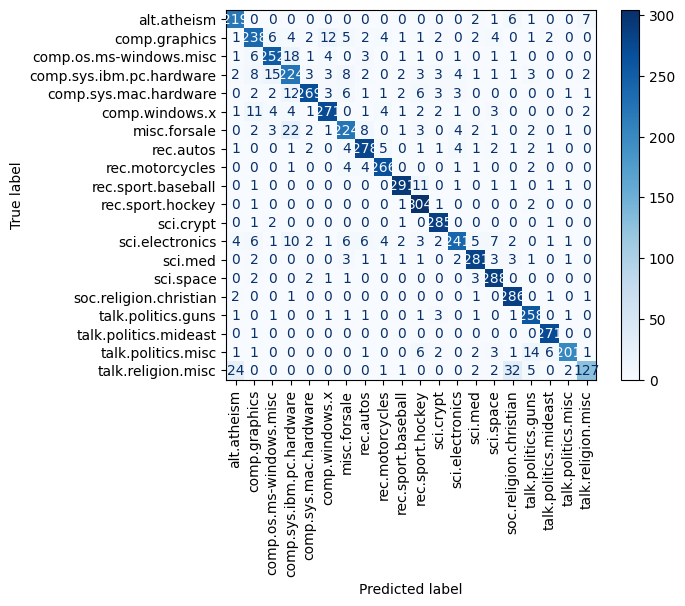

In [103]:
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=newsgroups.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=90)

In [105]:
params = {
    'alpha': [0.1, 0.5, 1.0, 2.0],
    'fit_prior': [True, False]
}

In [107]:
grid_search = GridSearchCV(best_model, param_grid=params, scoring='accuracy', cv=5)

In [109]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=ComplementNB(),
             param_grid={'alpha': [0.1, 0.5, 1.0, 2.0],
                         'fit_prior': [True, False]},
             scoring='accuracy')

In [113]:
best_model = grid_search.best_estimator_

In [115]:
y_pred = best_model.predict(X_test)

In [117]:
metrics.accuracy_score(y_test, y_pred)

0.9092677750265299

In [121]:
y_pred

array([ 9, 12, 14, ...,  0, 18,  1])

In [119]:
y_prob = best_model.predict_proba(X_test)
y_prob

array([[0.0243415 , 0.01613177, 0.01473395, ..., 0.01449079, 0.0160707 ,
        0.01723478],
       [0.00896945, 0.0144915 , 0.01691187, ..., 0.00754246, 0.00917039,
        0.00973939],
       [0.01527803, 0.01475465, 0.01433675, ..., 0.01530575, 0.01400196,
        0.01529821],
       ...,
       [0.82935324, 0.00801175, 0.00768729, ..., 0.0145679 , 0.00856953,
        0.01042866],
       [0.00178517, 0.00146506, 0.00145765, ..., 0.00173341, 0.96716421,
        0.00208423],
       [0.04277358, 0.1043781 , 0.07720838, ..., 0.03470894, 0.03837696,
        0.05040943]])

In [ ]:
# apple, book, ball, ...
# [0, 0, 1, ...]

In [131]:
y_prob[-1].argmax()

1

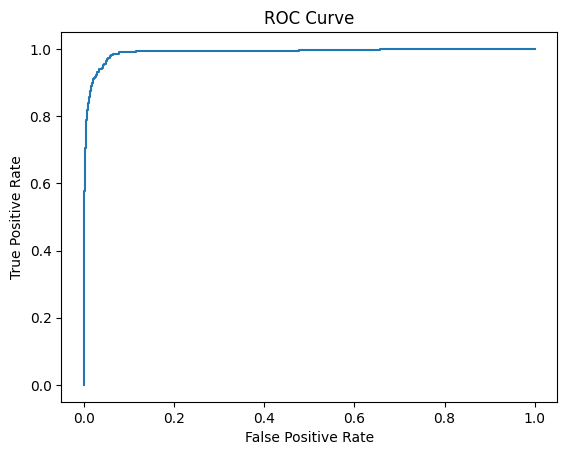

In [123]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_prob[:, 1], pos_label=1)
plt.plot(fpr, tpr, label='ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

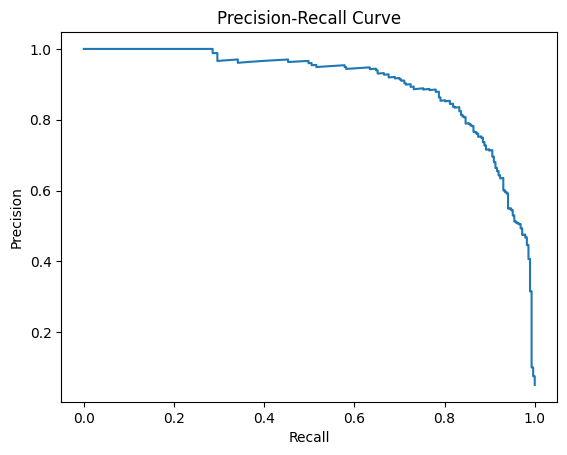

In [125]:
precision, recall, thresholds_pr = metrics.precision_recall_curve(y_test, y_prob[:, 1], pos_label=1)
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()